- 비지도 학습의 가장 대표적인 모델은 clustering
- 군집모델 중에서 가장 대표적인 모델이 (K Means Clustering)
- 정답(y)이 없는 데이터를 다루는 비지도학습
- kmeans로 데이터를 비슷한 그룹을 묶어줌
- Elbow 기법으로 적절한 cluster(군집) 수(k)를 정하는 모델
    - kmeans 모델의 원리
        - 중심점 k개를 랜덤하게 찍음
        - 각 점을 가장 가까운 중심에 배정
        - 그룹의 "평균"으로 중심을 이동
        - 변화가 없을 때까지 2~3회 반복
        - 정확도가 아니라 군집이 얼마나 잘 뭉쳐졌는지를 평가
      

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = "1"

In [2]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA #차원축소 수행, 불순물제거
from sklearn.metrics import confusion_matrix

In [6]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns = iris.feature_names)

In [7]:
X = iris.data
feature_names = iris.feature_names

print("사용할 입력 변수")
print(feature_names)

print(X.shape)

사용할 입력 변수
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
(150, 4)


# 데이터 스케일링

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [18]:
scaled_df = pd.DataFrame(X_scaled,columns = feature_names)
print(scaled_df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0            -0.900681          1.019004          -1.340227         -1.315444
1            -1.143017         -0.131979          -1.340227         -1.315444
2            -1.385353          0.328414          -1.397064         -1.315444
3            -1.506521          0.098217          -1.283389         -1.315444
4            -1.021849          1.249201          -1.340227         -1.315444
..                 ...               ...                ...               ...
145           1.038005         -0.131979           0.819596          1.448832
146           0.553333         -1.282963           0.705921          0.922303
147           0.795669         -0.131979           0.819596          1.053935
148           0.432165          0.788808           0.933271          1.448832
149           0.068662         -0.131979           0.762758          0.790671

[150 rows x 4 columns]


# elbow Method로 k후보 탐색

- 군집 개수 k를 결정
- k를 바꾸면서 inertia를 확인
    - inertia : 각 데이터가 자신이 속한 군집 중심점에서 떨어진 거리의 함
    - 값이 작을수록 군집 내부가 조밀함
    - k가 커질 수록 inertia는 계속 감소
    - 감소 폭이 갑자기 완만해지는 지점이 k 후보

In [10]:
inertias = []

K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

elbow_df = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias
})

elbow_df

,K,Inertia
0,1,600.000000
1,2,222.361705
2,3,139.820496
3,4,114.092547
4,5,90.927514
5,6,81.544391
6,7,72.631144
7,8,62.540606
8,9,55.119493
9,10,47.391035


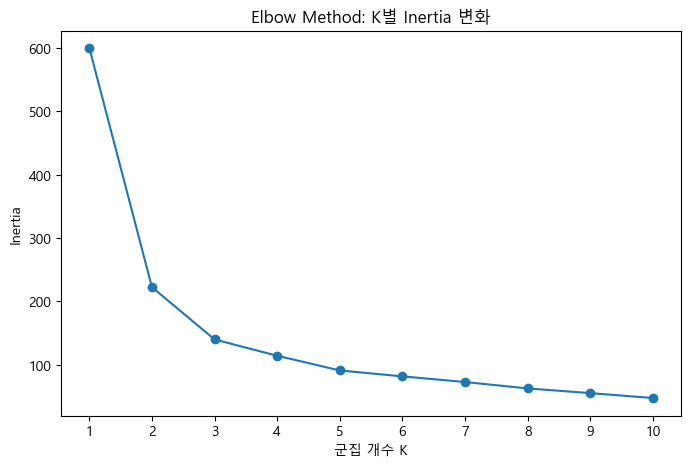

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(elbow_df["K"], elbow_df["Inertia"], marker="o")
plt.xlabel("군집 개수 K")
plt.ylabel("Inertia")
plt.title("Elbow Method: K별 Inertia 변화")
plt.xticks(list(K_range))
plt.show()
# 3으로 추정

# clustering 모델 평가 지표

1) Silhouette Score(실루엣 점수)
 - 1에 가까울 수록 좋음
 - 군집 내부는 가깝고 다른 군집과는 멀수록 높음

In [14]:
silhouette_results = []


# k = 1은 실루엣 계산이 불가능하므로 k=2부터 시작

for k in range(2,10):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels_temp=kmeans_temp.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels_temp)

    silhoutte_results.append({
        "k":k,
        "silhouette_score":sil
    })
silhouette_df = pd.DataFrame(silhouette_results)
    

NameError: name 'silhoutte_results' is not defined

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette_Score"],
    marker="o"
)

plt.xlabel("군집 개수 K")
plt.ylabel("Silhouette Score")
plt.title("K별 Silhouette Score 비교")
plt.xticks(silhouette_df["K"])
plt.grid(True)
plt.show()

In [20]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [ ]:
cluster_labels = kmeans.fit_predict(X_scaled)

cluster